In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [4]:
def bmi_calculator(state: BMIState) -> BMIState:
    state['bmi'] = state['weight_kg'] / (state['height_m'] ** 2)
    return state

In [3]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [5]:
# define the state graph
graph = StateGraph(BMIState)

#add nodes to the graph
graph.add_node("bmi_calculator", bmi_calculator)
graph.add_node("label_bmi", label_bmi)

#add edges to the graph
graph.add_edge(START, "bmi_calculator")
graph.add_edge("bmi_calculator", "label_bmi")
graph.add_edge("label_bmi", END)

#compile the graph
workflow = graph.compile()

#execute the graph
initial_state = BMIState(weight_kg=67, height_m=1.72)
final_state = workflow.invoke(initial_state)

In [6]:
final_state

{'weight_kg': 67,
 'height_m': 1.72,
 'bmi': 22.647376960519203,
 'category': 'Normal weight'}

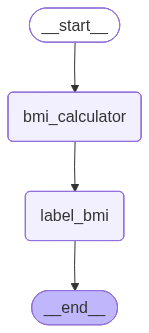

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())